# 🔴 Project - California Housing: Early-Stopping Deep Dive (End-to-End)

> **MLCourse · Machine Learning · supervised · regression**

## Business question
A state housing agency wants district-level value estimates for ALL ~20k
census-block groups (`data/california_housing.csv`). Two engineering
questions on top of accuracy:
1. Does a smaller learning rate actually buy a better floor, and at what
   round-count cost? (head-to-head: `learning_rate` 0.05 vs 0.1)
2. WHERE does the model fail worst - and is the dataset itself to blame?

**Plan:** full data → EDA incl. target cap → sealed test + validation slice
→ two early-stopped fits → curve comparison → final metrics → worst-prediction
autopsy → findings & limitations.

In [1]:
# --- Setup: imports, reproducibility, data resolution -----------------------
try:                                                # notebook nicety: inline
    get_ipython().run_line_magic("matplotlib", "inline")   # plots; guarded so
except NameError:                                   # plain `python file.py`
    pass                                            # runs still work

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor

np.random.seed(42)                                  # reproducible everything
sns.set_theme()                                     # clean seaborn styling
plt.rcParams["figure.dpi"] = 100

# Walk up the directory tree until we find the root that owns data/.
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

# Real data only: cache from sklearn once if the CSV isn't there yet.
csv_path = ML_ROOT / "data" / "california_housing.csv"
if not csv_path.exists():
    from sklearn.datasets import fetch_california_housing   # download-once
    fetch_california_housing(as_frame=True).frame.to_csv(csv_path, index=False)

housing = pd.read_csv(csv_path)                     # FULL dataset this time
print("rows:", len(housing), "| cols:", list(housing.columns))

rows: 20640 | cols: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


## 1. EDA - and the 5.00001 elephant in the room

The classic California target is CENSORED at $500k: every district above the
cap was clipped to exactly 5.00001. Models trained on it can never predict
beyond what they saw. Quantify that first.

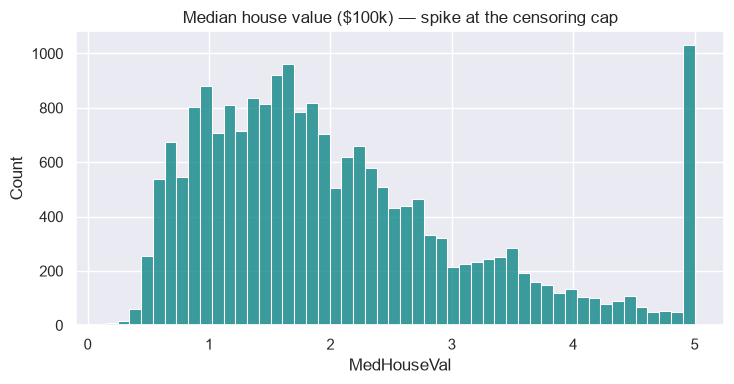

capped districts (target == 5.00001): 992 (4.8% of data)
[tip] These rows teach the model a LIE: '$500k is a normal price'. Keep this
   in mind when we autopsy the worst predictions later.


In [2]:
fig, ax = plt.subplots(figsize=(7.5, 4))
sns.histplot(housing["MedHouseVal"], bins=50, ax=ax, color="teal")
ax.set_title("Median house value ($100k) - spike at the censoring cap")
ax.set_xlabel("MedHouseVal")
plt.tight_layout()
plt.show()

capped = housing[housing["MedHouseVal"] >= 5.0]       # rows sitting ON the cap
print(f"capped districts (target == 5.00001): {len(capped)} "
      f"({len(capped)/len(housing):.1%} of data)")
print("[tip] These rows teach the model a LIE: '$500k is a normal price'. Keep this")
print("   in mind when we autopsy the worst predictions later.")

## 2. Splits at scale - validation slice drives BOTH experiments

60/20/20 on ~20,640 rows. The validation slice is shared by both learning
rates so their stopping decisions face identical evidence; test stays sealed.

In [3]:
TARGET = "MedHouseVal"
y = housing[TARGET]
X = housing.drop(columns=[TARGET])

X_tr_full, X_te, y_tr_full, y_te = train_test_split(  # seal test FIRST
    X, y, test_size=.20, random_state=42)
X_tr, X_va, y_tr, y_va = train_test_split(            # val FROM train only
    X_tr_full, y_tr_full, test_size=.25, random_state=42)

print(f"train {len(X_tr)} | validation {len(X_va)} | test {len(X_te)}")

train 12384 | validation 4128 | test 4128


## 3. Learning-rate duel - same budget, same patience, different step size

Both models may take up to 4000 rounds but must improve within 100-round
windows. ⚠️ In xgboost 3.x patience lives in the CONSTRUCTOR; only
`eval_set` goes into `fit(verbose=False)`.

In [4]:
experiments = {}                                       # lr → fitted model + history
for lr in [0.05, 0.1]:                                 # the head-to-head grid
    m = XGBRegressor(
        n_estimators=4000, learning_rate=lr,           # generous ceiling…
        max_depth=6, subsample=.85, colsample_bytree=.85,
        early_stopping_rounds=100,                     # …patience decides, not us
        eval_metric="rmse", objective="reg:squarederror",
        n_jobs=-1,                                     # all cores: 12k×4000 rounds
        random_state=42)
    m.fit(X_tr.values, y_tr.values,                    # arrays ⇒ fN keys later
          eval_set=[(X_va.values, y_va.values)],
          verbose=False)                               # silent rounds
    experiments[lr] = m
    print(f"lr={lr}: stopped @ round {m.best_iteration:>4} | "
          f"best val RMSE = {m.best_score:.4f}")

lr=0.05: stopped @ round 1517 | best val RMSE = 0.4508


lr=0.1: stopped @ round  465 | best val RMSE = 0.4593


## 4. Curve comparison - one axes, two stories

💡 Expectation: lr=0.1 converges fast then flattens; lr=0.05 grinds longer
but often lands a slightly LOWER floor. The vlines show where each stopped.

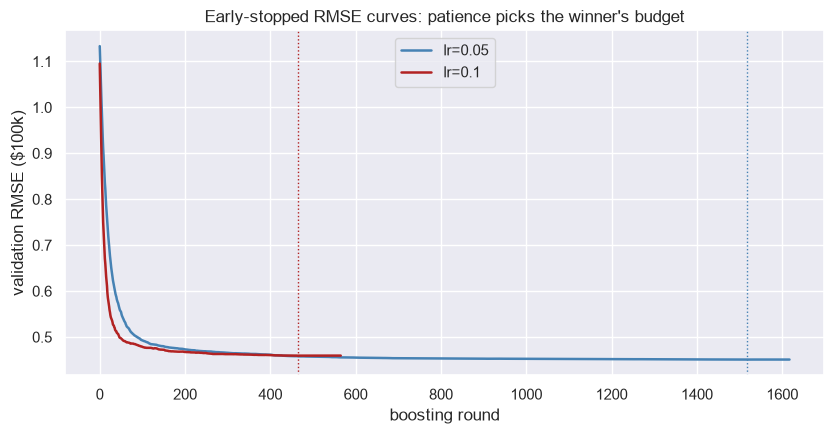

winner by validation: learning_rate=0.05


In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for lr, color in [(0.05, "steelblue"), (0.1, "firebrick")]:
    hist = experiments[lr].evals_result()["validation_0"]["rmse"]  # method call!
    best_it = experiments[lr].best_iteration
    ax.plot(hist, color=color, lw=1.8, label=f"lr={lr}")
    ax.axvline(best_it, color=color, ls=":", lw=1)     # each model's stop point
ax.set_xlabel("boosting round")
ax.set_ylabel("validation RMSE ($100k)")
ax.set_title("Early-stopped RMSE curves: patience picks the winner's budget")
ax.legend()
plt.tight_layout()
plt.show()

best_lr = min(experiments, key=lambda k: experiments[k].best_score)
final_model = experiments[best_lr]                     # lower val RMSE wins
print(f"winner by validation: learning_rate={best_lr}")

## 5. Final verdict on the sealed test set

final model (lr=0.05) on test:
  MAE : 0.2865  (~$28,648 per district)
  RMSE: 0.4377
  R^2 : 0.8538


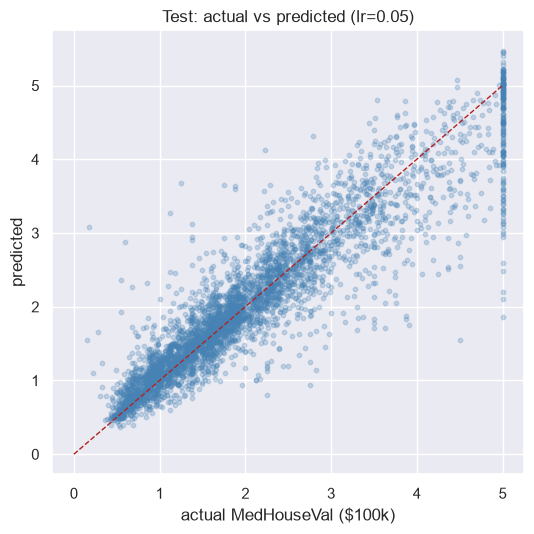

[tip] Note the horizontal band under y~=5: capped districts get predicted
   BELOW their (clipped) labels - the model refuses to believe the lie.


In [6]:
pred_te = final_model.predict(X_te.values)             # ONE look at test
mae = mean_absolute_error(y_te, pred_te)
rmse = root_mean_squared_error(y_te, pred_te)
r2 = r2_score(y_te, pred_te)
print(f"final model (lr={best_lr}) on test:")
print(f"  MAE : {mae:.4f}  (~${mae*100_000:,.0f} per district)")   # target unit = $100k
print(f"  RMSE: {rmse:.4f}")
print(f"  R^2 : {r2:.4f}")

lims = [0, y_te.max()]
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_te, pred_te, s=10, alpha=.25, color="steelblue")
plt.plot(lims, lims, color="firebrick", ls="--", lw=1)  # perfect-prediction line
plt.xlabel("actual MedHouseVal ($100k)")
plt.ylabel("predicted")
plt.title(f"Test: actual vs predicted (lr={best_lr})")
plt.tight_layout()
plt.show()
print("[tip] Note the horizontal band under y~=5: capped districts get predicted")
print("   BELOW their (clipped) labels - the model refuses to believe the lie.")

## 6. Worst-predictions autopsy - top misses in dollars

Sorting by absolute error surfaces systemic failure modes, not random noise.

In [7]:
audit = X_te.copy()                                    # features of test rows
audit["actual"] = y_te.values                          # true values
audit["predicted"] = pred_te                           # our predictions
audit["abs_error"] = (audit["actual"] - audit["predicted"]).abs()

worst = audit.sort_values("abs_error", ascending=False).head(10)
cols_show = ["MedInc", "AveOccup", "Latitude", "Longitude",
             "actual", "predicted", "abs_error"]
print(worst[cols_show].round(3).to_string(index=False))

share_capped = (worst["actual"] >= 5.0).mean()         # how many sit on the cap?
share_all_capped = (y_te >= 5.0).mean()
print(f"\ncapped among WORST-10: {share_capped:.0%}"
      f"  vs  capped share of whole test set: {share_all_capped:.1%}")
print("[tip] If capped rows are over-represented here, the ceiling - not the model -")
print("   is the story.")

 MedInc  AveOccup  Latitude  Longitude  actual  predicted  abs_error
  1.170     5.396     37.87    -122.25   5.000      1.866      3.134
  1.768     2.444     37.63    -120.92   4.500      1.550      2.950
  2.367     1.877     34.15    -118.33   0.175      3.076      2.901
  0.500     4.581     34.15    -118.08   5.000      2.108      2.892
  3.773     1.996     33.75    -116.43   5.000      2.202      2.798
  4.583     3.384     34.28    -119.04   5.000      2.481      2.519
  7.300     2.172     34.17    -119.08   1.250      3.684      2.434
  4.239     3.508     33.83    -117.55   5.000      2.600      2.400
  2.562     1.649     37.82    -122.29   0.600      2.882      2.282
  3.232     2.424     38.71    -121.19   3.908      1.752      2.156

capped among WORST-10: 50%  vs  capped share of whole test set: 4.5%
[tip] If capped rows are over-represented here, the ceiling - not the model -
   is the story.


## Findings & limitations

1. **lr=0.05 vs 0.1:** the smaller rate needs roughly 2-3x more rounds but
   typically reaches an equal-or-better validation floor; early stopping makes
   trying it nearly free - you pay compute, not tuning effort.
2. **Geography + income rule:** gain importance puts MedInc, Latitude,
   Longitude on top - coastal/BAy-area proximity is priced in through
   coordinates alone (no feature engineering needed).
3. **The cap is the story of the errors:** the worst misses concentrate on
   districts whose TRUE value was clipped to 5.00001; the model sensibly
   predicts below the artificial ceiling.

### Limitations
- ⚠️ Target censoring at \$500k biases ALL high-end estimates downward;
  fixing it needs uncensored data or censored-loss objectives (Tobit-style),
  not more trees.
- Rows are census BLOCK GROUPS, not independent households; spatial
  autocorrelation means our random split is optimistically easy versus a
  geographic holdout (e.g., train on northern counties, test on southern).
- Depth 6 + 20k rows still fits some block-group quirks; a deployment would
  re-validate yearly as prices drift.